# Problem Statement:
Car Data- Here, we will apply k-means clustering for grouping the similar cars in one cluster

# Q1. Load the Cars Data and necesary modules file into Python DataFrame and view top 10 rows

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pylab as plt
%matplotlib inline

import seaborn as sns
from sklearn.model_selection  import train_test_split
from sklearn.cluster import KMeans

from scipy.stats import zscore

#import sklearn.metrics

cars_df = pd.read_csv("download-3.csv")
cars_df.head()


,mpg,cyl,disp,hp,wt,acc,yr,origin,car_name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [3]:
cars_df.describe()

,mpg,cyl,disp,wt,acc,yr,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


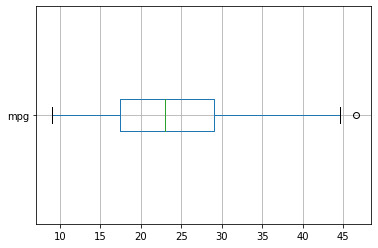

In [4]:
boxplot = cars_df.boxplot(column=['mpg'],vert=False)
# Slightly Right skewed


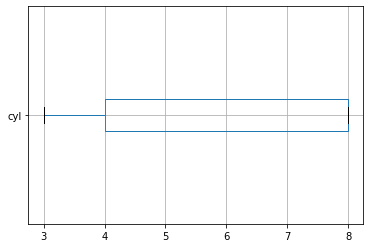

In [5]:
boxplot = cars_df.boxplot(column=['cyl'],vert=False)

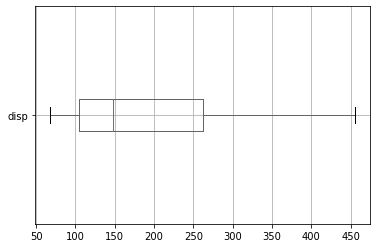

In [6]:
boxplot = cars_df.boxplot(column=['disp'],vert=False)

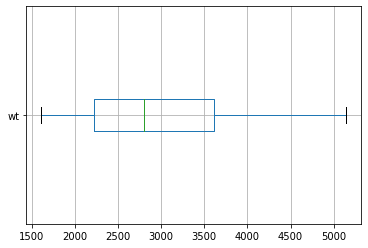

In [7]:
boxplot = cars_df.boxplot(column=['wt'],vert=False)

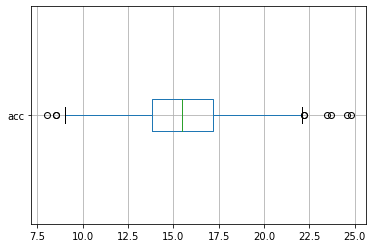

In [8]:
boxplot = cars_df.boxplot(column=['acc'],vert=False)

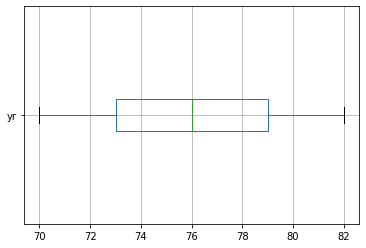

In [9]:
boxplot = cars_df.boxplot(column=['yr'],vert=False)

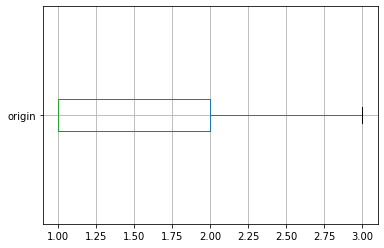

In [10]:

boxplot = cars_df.boxplot(column=['origin'],vert=False)

# Q2.  Print the datatypes of each column and the shape of the dataset. Perform descriptive analysis

In [11]:
cars_df.dtypes


mpg         float64
cyl           int64
disp        float64
hp           object
wt            int64
acc         float64
yr            int64
origin        int64
car_name     object
dtype: object

In [12]:
cars_df.shape

(398, 9)

# Q3. Check for missing value check, incorrect data and perform imputation with mean, median and mode as necessary

In [13]:
cars_df.isnull().values.any()

False

In [14]:
cars_df.applymap(np.isreal)

,mpg,cyl,disp,hp,wt,acc,yr,origin,car_name
0,True,True,True,False,True,True,True,True,False
1,True,True,True,False,True,True,True,True,False
2,True,True,True,False,True,True,True,True,False
3,True,True,True,False,True,True,True,True,False
4,True,True,True,False,True,True,True,True,False
...,...,...,...,...,...,...,...,...,...
393,True,True,True,False,True,True,True,True,False
394,True,True,True,False,True,True,True,True,False
395,True,True,True,False,True,True,True,True,False
396,True,True,True,False,True,True,True,True,False


In [15]:
cars_df.hp.unique()

array(['130', '165', '150', '140', '198', '220', '215', '225', '190',
       '170', '160', '95', '97', '85', '88', '46', '87', '90', '113',
       '200', '210', '193', '?', '100', '105', '175', '153', '180', '110',
       '72', '86', '70', '76', '65', '69', '60', '80', '54', '208', '155',
       '112', '92', '145', '137', '158', '167', '94', '107', '230', '49',
       '75', '91', '122', '67', '83', '78', '52', '61', '93', '148',
       '129', '96', '71', '98', '115', '53', '81', '79', '120', '152',
       '102', '108', '68', '58', '149', '89', '63', '48', '66', '139',
       '103', '125', '133', '138', '135', '142', '77', '62', '132', '84',
       '64', '74', '116', '82'], dtype=object)

In [16]:
cars_df['hp'].replace("?",np.nan, inplace=True)
cars_df.hp.count()


392

In [17]:
hp = cars_df['hp'].dropna()
cars_df.hp.count()

392

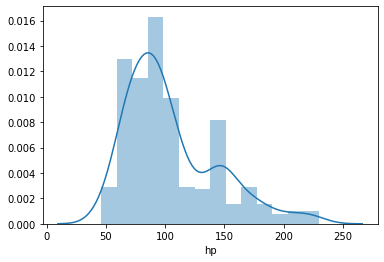

In [18]:
import seaborn as sns
sns.distplot(pd.to_numeric(hp))


In [19]:
# Since this does not look to be normally distributed, let us impute by using median
cars_df['hp'].fillna((cars_df['hp'].median()), inplace=True)
cars_df['hp'] = cars_df['hp'].astype('float')

# Q4. Perform bi variate analysis including correlation, pairplots and state the inferences

In [20]:
cars_df.corr(method='kendall')

,mpg,cyl,disp,hp,wt,acc,yr,origin
mpg,1.000000,-0.686477,-0.679847,-0.673377,-0.694006,0.301096,0.413661,0.467249
cyl,-0.686477,1.000000,0.794854,0.682006,0.735481,-0.367194,-0.273742,-0.551610
disp,-0.679847,0.794854,1.000000,0.711556,0.800508,-0.352110,-0.218920,-0.570074
hp,-0.673377,0.682006,0.711556,1.000000,0.696368,-0.482267,-0.274888,-0.402494
wt,-0.694006,0.735481,0.800508,0.696368,1.000000,-0.268619,-0.196863,-0.496185
acc,0.301096,-0.367194,-0.352110,-0.482267,-0.268619,1.000000,0.196024,0.173055
yr,0.413661,-0.273742,-0.218920,-0.274888,-0.196863,0.196024,1.000000,0.136967
origin,0.467249,-0.551610,-0.570074,-0.402494,-0.496185,0.173055,0.136967,1.000000


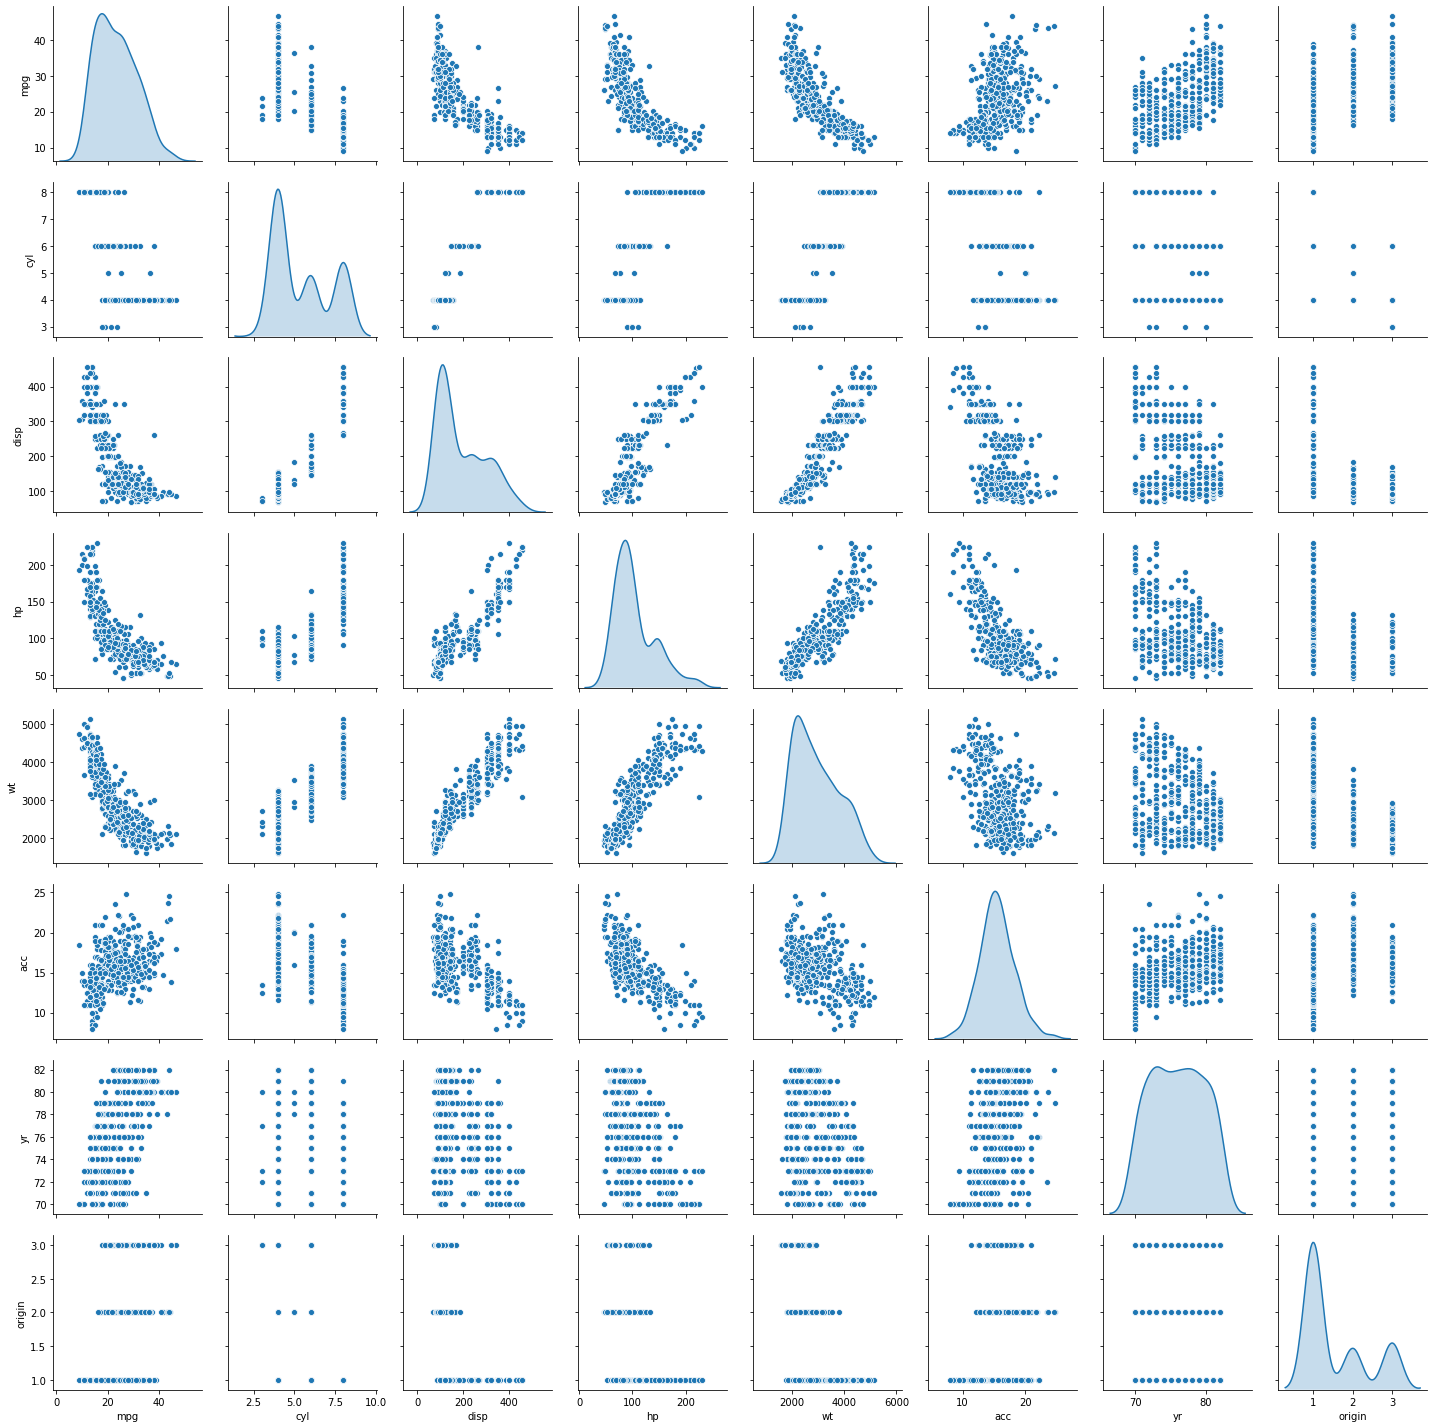

In [21]:
sns.pairplot(cars_df,diag_kind='kde')

# Q5. Perform any feature engineering/transformation and remove any duplicate or irrelevant columns

In [22]:
cars_df['age'] = 83-cars_df['yr']
cars_df.head()

,mpg,cyl,disp,hp,wt,acc,yr,origin,car_name,age
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu,13
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320,13
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite,13
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst,13
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino,13


In [25]:
#Convert origing into dummy variables (This again is subjected to business knowledge. We might drop this variable as well
# Inclusion is more to demonstrate on how to use categorical data)

one_hot = pd.get_dummies(cars_df['origin'])
one_hot = one_hot.add_prefix('origin_')

# merge in main data frame
cars_df = cars_df.join(one_hot)
cars_df.head()

,mpg,cyl,disp,hp,wt,acc,yr,origin,car_name,age,origin_1,origin_2,origin_3
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu,13,1,0,0
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320,13,1,0,0
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite,13,1,0,0
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst,13,1,0,0
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino,13,1,0,0


In [27]:
# drop Origin
cars_new = cars_df.drop(['yr','origin','car_name'], axis =1)

cars_new.head()

,mpg,cyl,disp,hp,wt,acc,age,origin_1,origin_2,origin_3
0,18.0,8,307.0,130.0,3504,12.0,13,1,0,0
1,15.0,8,350.0,165.0,3693,11.5,13,1,0,0
2,18.0,8,318.0,150.0,3436,11.0,13,1,0,0
3,16.0,8,304.0,150.0,3433,12.0,13,1,0,0
4,17.0,8,302.0,140.0,3449,10.5,13,1,0,0


# Q6. Create new data frame with standardize variables and imputation for any missing/outliers

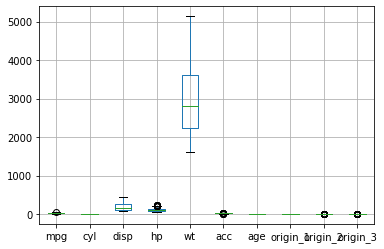

In [28]:
cars_new.boxplot()

{'whiskers': [<matplotlib.lines.Line2D at 0x1a21da65d0>,
 'caps': [<matplotlib.lines.Line2D at 0x1a21da6650>,
 'boxes': [<matplotlib.lines.Line2D at 0x1a21d9f950>],
 'medians': [<matplotlib.lines.Line2D at 0x1a21db0a90>],
 'fliers': [<matplotlib.lines.Line2D at 0x1a21db0f90>],
 'means': []}

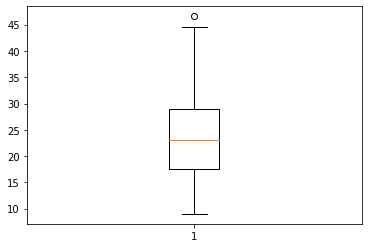

In [29]:
# We could see some outliers for mpg,hp and acc
plt.boxplot(cars_new['mpg'])

{'whiskers': [<matplotlib.lines.Line2D at 0x1a21e14450>,
 'caps': [<matplotlib.lines.Line2D at 0x1a21e14f10>,
 'boxes': [<matplotlib.lines.Line2D at 0x1a21e0d7d0>],
 'medians': [<matplotlib.lines.Line2D at 0x1a21e87990>],
 'fliers': [<matplotlib.lines.Line2D at 0x1a21e87e90>],
 'means': []}

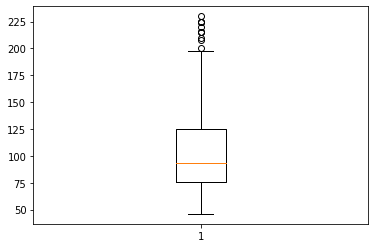

In [30]:
plt.boxplot(cars_new['hp'])

{'whiskers': [<matplotlib.lines.Line2D at 0x1a21f5c390>,
 'caps': [<matplotlib.lines.Line2D at 0x1a21f5ce50>,
 'boxes': [<matplotlib.lines.Line2D at 0x1a21f53710>],
 'medians': [<matplotlib.lines.Line2D at 0x1a21f648d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1a21f64dd0>],
 'means': []}

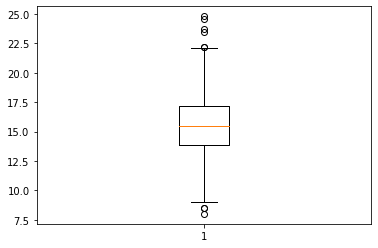

In [31]:
plt.boxplot(cars_new['acc'])

In [32]:
# Let us take logaritmic transform for hp,mpg and acc to remove outliers
cars_new['hp'] = np.log(cars_new['hp'])
cars_new['acc'] = np.log(cars_new['acc'])
cars_new['mpg'] = np.log(cars_new['mpg'])

cars_new.head()

,mpg,cyl,disp,hp,wt,acc,age,origin_1,origin_2,origin_3
0,2.890372,8,307.0,4.867534,3504,2.484907,13,1,0,0
1,2.708050,8,350.0,5.105945,3693,2.442347,13,1,0,0
2,2.890372,8,318.0,5.010635,3436,2.397895,13,1,0,0
3,2.772589,8,304.0,5.010635,3433,2.484907,13,1,0,0
4,2.833213,8,302.0,4.941642,3449,2.351375,13,1,0,0


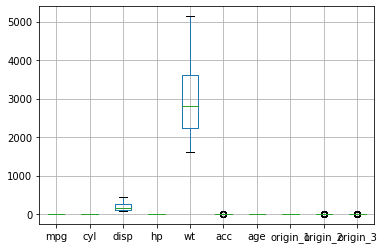

In [33]:
cars_new.boxplot()

In [35]:
# This looks better.
# Now let us try to scale the variables
from scipy.stats import zscore

cars_new.dtypes
numeric_cols = cars_new.select_dtypes(include=[np.int64, np.float64]).columns
numeric_cols
cars_new[numeric_cols] =cars_new[numeric_cols].apply(zscore)
cars_new.head()






,mpg,cyl,disp,hp,wt,acc,age,origin_1,origin_2,origin_3
0,-0.622035,1.498191,1.090604,0.823608,0.630870,-1.353748,1.627426,1,0,0
1,-1.159493,1.498191,1.503514,1.523992,0.854333,-1.589535,1.627426,1,0,0
2,-0.622035,1.498191,1.196232,1.243998,0.550470,-1.835805,1.627426,1,0,0
3,-0.969242,1.498191,1.061796,1.243998,0.546923,-1.353748,1.627426,1,0,0
4,-0.790530,1.498191,1.042591,1.041316,0.565841,-2.093533,1.627426,1,0,0


# Q7. Create appropriate clusters with the new data set

In [36]:
# Variables are mow scaled. Let us now try to create clusters

cluster_range = range(1,15)
cluster_errors = []
for num_clusters in cluster_range:
    clusters = KMeans(num_clusters, n_init = 5)
    clusters.fit(cars_new)
    labels = clusters.labels_
    centroids = clusters.cluster_centers_
    cluster_errors.append(clusters.inertia_)

clusters_df = pd.DataFrame({"num_clusters": cluster_range, "cluster_errors": cluster_errors})
clusters_df[0:15]

,num_clusters,cluster_errors
0,1,3000.226131
1,2,1435.661694
2,3,1072.434353
3,4,873.696202
4,5,786.882347
5,6,719.032886
6,7,671.729014
7,8,627.620783
8,9,593.631354
9,10,560.752877


# Q8. Identify the appropriate clusters with result from above question

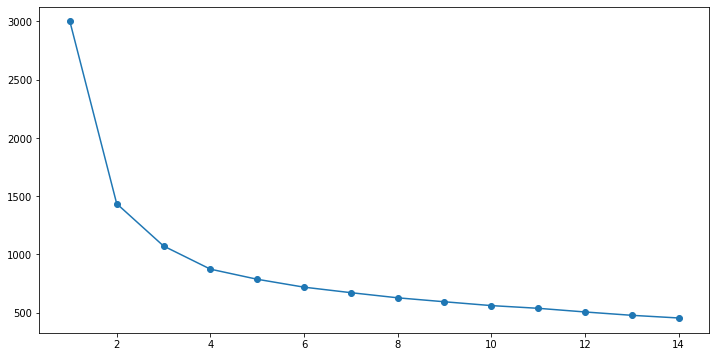

In [37]:
from matplotlib import cm

plt.figure(figsize=(12,6))
plt.plot( clusters_df.num_clusters, clusters_df.cluster_errors, marker = "o" )

In [38]:
# We could see the bend at 4, so let us create 4 custers

kmeans = KMeans(n_clusters=4, n_init = 5, random_state=12345)
kmeans.fit(cars_new)

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
       n_clusters=4, n_init=5, n_jobs=None, precompute_distances='auto',
       random_state=12345, tol=0.0001, verbose=0)

# Q9. Check for no of values in each cluster and centers for each variables

In [39]:
# Distribution looks fine.

# let us check the centers in each group
centroids = kmeans.cluster_centers_
centroid_df = pd.DataFrame(centroids, columns = list(cars_new) )
centroid_df.transpose()

,0,1,2,3
mpg,-1.306300e+00,1.080530,0.337373,-0.395798
cyl,1.498191e+00,-0.821104,-0.868584,0.424430
disp,1.503923e+00,-0.773034,-0.824059,0.309735
hp,1.442656e+00,-0.799132,-0.545073,0.112262
wt,1.404098e+00,-0.748370,-0.770282,0.324409
acc,-1.150226e+00,0.426220,0.308195,0.315020
age,6.883238e-01,-1.087358,0.657116,-0.006206
origin_1,1.000000e+00,0.410256,0.250000,0.912088
origin_2,-3.053113e-16,0.188034,0.468750,0.032967
origin_3,2.498002e-16,0.401709,0.281250,0.054945


In [40]:
# Group 1 has highest values for mpg while 3rd has lowest
# Group 0 has max no of cylinders and 2 forms of lower cylinder values
# As seen in correlation and pairplot, Group 0 has highest values for hp,wt and displ
# Group 1 seems to be comprising of newest cars
# Group 3 and 0 seems to be originated at point 3, while 2 in 2nd point and 1 again at point 3

# Q10. Assign the groups created above to data frame and study the characteristics for each group.

In [43]:
# Add cluster number to original cars data

predictions = kmeans.predict(cars_new)
predictions
cars_df["group"] = predictions
cars_df['group'] = cars_df['group'].astype('category')
cars_df.dtypes

mpg          float64
cyl            int64
disp         float64
hp           float64
wt             int64
acc          float64
yr             int64
origin         int64
car_name      object
age            int64
origin_1       uint8
origin_2       uint8
origin_3       uint8
group       category
dtype: object

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x1a2280e610>,
      dtype=object)

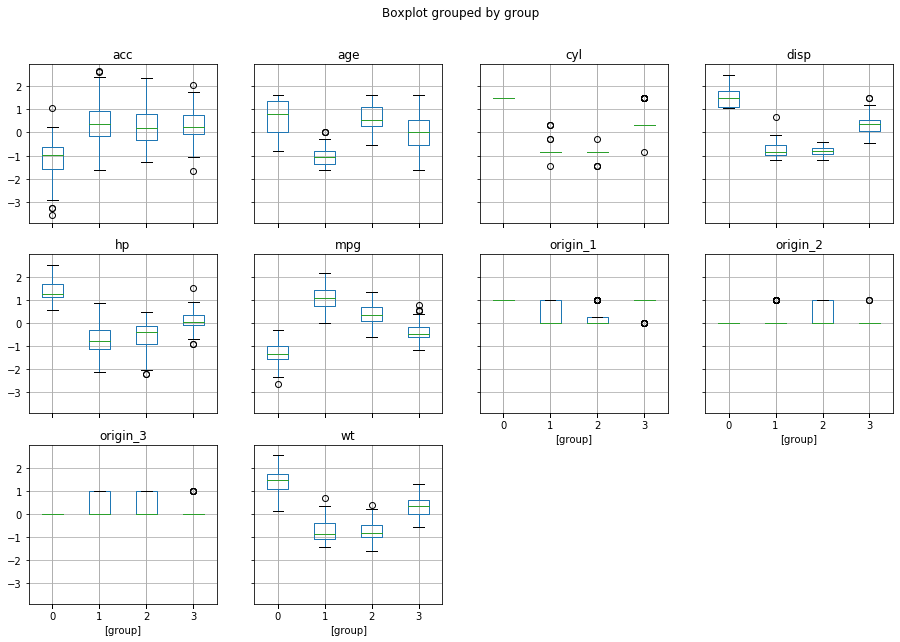

In [44]:
# Visualize the centers

cars_new["group"] = predictions
cars_new.boxplot(by = 'group',  layout=(3,4), figsize=(15, 10))

In [45]:
# Group 0 is characterised by lower acc, comparitely old models, higher wt, hp but lowest mpg with origin at 1
# Group 1 -Highest mpg, lower wt and hp. Lower age limits suggest comparitevly newer cars. Origin looks more 2
# Group 2 - Origin mostly in location 2, lower deviation in wts, and hp so medain mpg and acceleration
# Group 3 - Again slighlty higher in wt origin code as 1. Better performance in terms of mpg